# Inference & Optimization Pipeline: Fitting a Self-Consistent Galaxy Model

Given an **observed** galaxy (here a synthetic stand-in — mass, line-of-sight rotation velocity, and velocity-dispersion maps), `phoenix.optimization.pipeline` fits potential parameters (`pot_params`) and distribution-function parameters (`disk_df_params`, `bulge_df_params`) so that:

1. **Data fit** — the Phoenix surrogate's predicted maps match the observation.
2. **Dynamical self-consistency** — the density implied by the fitted DF sources the fitted potential via the **Poisson equation** ($\nabla^2\Phi = 4\pi G\rho$).

Both are combined into one scalar loss and optimized with gradient descent (`optax.adam`) through the fully-differentiable pipeline (gradients verified in `gradient_check.ipynb`).

**This notebook focuses on a hard case: a starting guess far from the truth.** A naive fit gets stuck; the second half diagnoses why and shows the fixes that make it converge.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from phoenix.actions_to_phasespace.actions_to_phasespace_nn import PhoenixMapper
from phoenix.optimization.observables import generate_edge_on_maps
from phoenix.optimization.pipeline import make_observation, fit, fit_multistart

/home/annalena/phoenix/phoenix/distribution_functions/disk.py:14: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one of the two lines below.
from typeguard import typechecked as typechecker
from beartype import beartype as typechecker

@jaxtyped(typechecker=typechecker)
def foo(...):
```
and the old double-decorator syntax
```
@jaxtyped
@typechecker
def foo(...):
```
should no longer be used. (It will continue to work as it did before, but the new approach will produce more readable error messages.)
In particular note that `typechecker` must be passed via keyword argument; the following is not valid:
```
@jaxtyped(typechecker)
def foo(...):
```

  @jaxtyped
/home/annalena/phoenix/phoenix/distribution_functions/disk.py:21: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one o

## 1. The Toy 'Galaxy' and its 'Observed' Maps

We stand in for a real observation with a synthetic galaxy from a chosen ground truth. The observation uses the *same* sampling seed/particle-count/grid as the fitting loss (a standard 'twin experiment'): this isolates the inverse-problem question (can we recover the parameters from a bad guess?) from unrelated Monte-Carlo shot noise. Replace `obs_maps` with real maps on the same grid to fit actual data.

In [2]:
pot_params_true = {
    'M_halo': 1e12, 'a_halo': 20.0,
    'M_disk': 5e10, 'a_disk': 3.0, 'b_disk': 0.3,
    'M_bulge': 1e10, 'a_bulge': 1.0
}
disk_df_params_true = {
    "R0": 8.0, "Rd": 3.0, "Sigma0": 1000.0,
    "RsigR": 6.0, "RsigZ": 6.0,
    "sigmaR0_R0": 35.0, "sigmaz0_R0": 20.0,
    "L0": 10.0, "Rinit_for_Rc": 8.0
}
bulge_df_params_true = {
    "N0_spheroid": 1e10, "J0_spheroid": 100.0,
    "Gamma_spheroid": 1.5, "Beta_spheroid": 4.5, "eta_spheroid": 1.0
}

mapper = PhoenixMapper()

SEED = 0
N_PARTICLES = 6_000
GRID_SIZE = 14
EXTENT_X, EXTENT_Z = 15.0, 10.0

obs_maps = make_observation(
    mapper, pot_params_true, disk_df_params_true, bulge_df_params_true,
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
    extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED, noise_frac=0.0,
)

mass_mask = np.array(obs_maps['mass']) > 1e-3
vmax_mass = float(np.nanmax(np.array(obs_maps['mass'])))

Loading Phoenix Surrogate Model...
 -> Weights: /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_weights.msgpack
 -> Stats:   /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_norm_stats.npz


Model loaded and ready for inference!


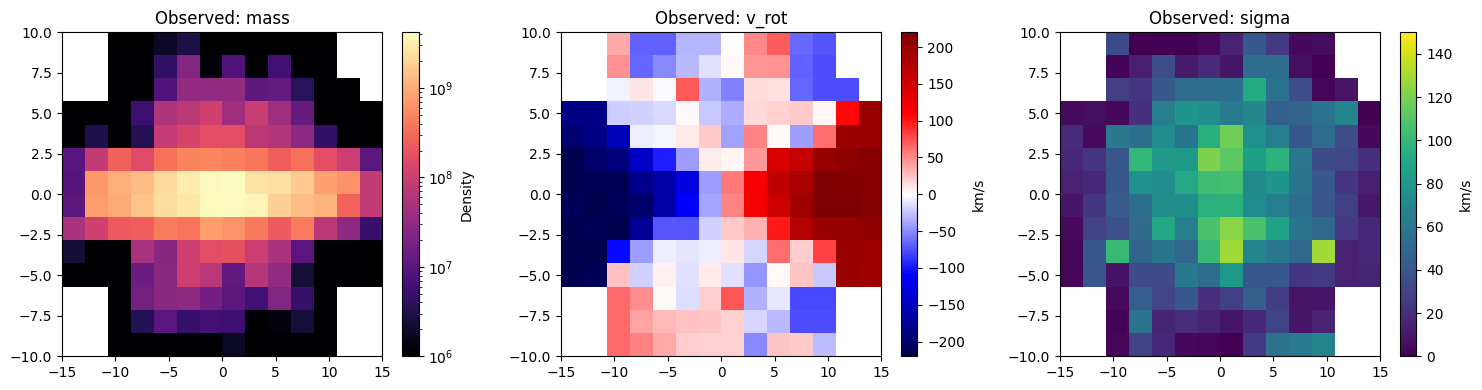

In [3]:
def plot_maps_row(axes, maps, mask, title_prefix, vmax_mass):
    extent = [-EXTENT_X, EXTENT_X, -EXTENT_Z, EXTENT_Z]
    mass = np.where(mask, np.array(maps['mass']), np.nan)
    vrot = np.where(mask, np.array(maps['v_rot']), np.nan)
    sigma = np.where(mask, np.array(maps['sigma']), np.nan)
    im0 = axes[0].imshow(mass, origin='lower', extent=extent, cmap='magma',
                          norm=LogNorm(vmin=1e6, vmax=vmax_mass), aspect='auto')
    axes[0].set_title(f'{title_prefix}: mass')
    im1 = axes[1].imshow(vrot, origin='lower', extent=extent, cmap='seismic', vmin=-220, vmax=220, aspect='auto')
    axes[1].set_title(f'{title_prefix}: v_rot')
    im2 = axes[2].imshow(sigma, origin='lower', extent=extent, cmap='viridis', vmin=0, vmax=150, aspect='auto')
    axes[2].set_title(f'{title_prefix}: sigma')
    return im0, im1, im2

def recovery(res):
    all_true = {**pot_params_true, **disk_df_params_true, **bulge_df_params_true}
    allf = {**res['pot_params'], **res['disk_df_params'], **res['bulge_df_params']}
    errs = {k: abs(allf[k] - all_true[k]) / abs(all_true[k]) * 100 for k in all_true}
    med = float(np.median(list(errs.values())))
    n_good = sum(e < 20 for e in errs.values())
    return med, n_good, errs

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ims = plot_maps_row(axes, obs_maps, mass_mask, 'Observed', vmax_mass)
for im, ax, lab in zip(ims, axes, ['Density', 'km/s', 'km/s']):
    fig.colorbar(im, ax=ax, label=lab)
plt.tight_layout(); plt.show()

## 2. A Far-Off Starting Guess

This is the regime that motivates the notebook: the initial guess is *far* from the truth — the potential parameters are ~5x too large, the disk 2.5x, and the bulge 10x too small. A realistic situation when you have no good prior estimate.

In [4]:
pot_params_init = {k: v * 5.3 for k, v in pot_params_true.items()}
disk_df_params_init = {k: v * 2.5 for k, v in disk_df_params_true.items()}
bulge_df_params_init = {k: v * 0.1 for k, v in bulge_df_params_true.items()}

init_maps = generate_edge_on_maps(
    mapper, pot_params_init, disk_df_params_init, bulge_df_params_init,
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
    extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED,
)

## 3. Naive Fit — and Why It Gets Stuck

First, a plain fit from the far start (fixed smoothing bandwidth). Watch the loss: it drops a little, then **plateaus at a high value and refuses to descend further**.

In [5]:
result_naive = fit(
    mapper, obs_maps,
    pot_params_init, disk_df_params_init, bulge_df_params_init,
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
    extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED,
    loss_weights=(1.0, 1.0, 1.0, 0.1), poisson_kwargs={},
    learning_rate=0.05, n_steps=400,
)
hn = result_naive['history']
med, ng, _ = recovery(result_naive)
print(f"NAIVE fit:  loss {hn['loss'][0]:.3f} -> {hn['loss'][-1]:.3f}")
print(f"            median param error {med:.0f}%, params within 20%: {ng}/21")
print("            loss curve:", [f"{x:.2f}" for x in hn['loss'][::50]])

NAIVE fit:  loss 6.460 -> 3.625
            median param error 257%, params within 20%: 2/21
            loss curve: ['6.46', '3.98', '3.28', '2.72', '2.57', '2.92', '2.58', '3.76']


### What is happening?

The plateau is **not** a 'needs more steps / bigger learning rate' problem (raising either doesn't help — the loss just oscillates around the same high value). It is a **vanishing gradient** in the data-fit term:

- The mass loss is a masked log comparison, evaluated only over pixels where the *observation* has mass. When the far-start model galaxy is displaced/mis-scaled, it puts almost no mass in those observed-bright pixels, so there `log10(model + floor) ≈ log10(floor)` — a large but **flat** penalty. Flat ⇒ near-zero gradient ⇒ the optimizer gets no signal about which way to move. The model and the data maps simply don't overlap.

Two more failure modes lurk near or beyond this regime, both already handled in the pipeline:

- **NaNs from the sampler.** The rejection-sampling envelope used to be calibrated from the DF at one hard-coded action point; for far/small parameters that value underflows to 0, and the soft-acceptance step divides by it. `sample_df_potential` now auto-calibrates the envelope from the candidates' own maximum DF (floored), which can't underflow to zero.
- **A biased self-consistency term.** The Poisson penalty compares a fixed-bandwidth KDE estimate of the tracer density against the exact analytic density; the KDE sits ~1 dex low even at the *true* parameters, so an absolute comparison isn't minimized at the truth and actively pulls the fit off-target. `compute_poisson_penalty(shape_only=True)` (now the default) compares only the *profile shape*, removing that bias — total mass is already pinned by the data mass-map. Its weight is also kept modest (`w_poisson=0.1`).

## 4. The Fix: Graduated (Coarse-to-Fine) Optimization

The cure for the vanishing-gradient plateau is **bandwidth annealing**: start with a *wide* KDE smoothing bandwidth so both the model and observed maps are broad and **overlap** — giving a non-zero gradient everywhere that pulls the model toward the data — then shrink the bandwidth over the run to recover a sharp final fit. `fit(..., anneal_bandwidth=(h_start, h_end))` decays the bandwidth log-linearly. (Annealing too fast can destabilize once maps get sharp again, so give it enough steps.)

In [6]:
result = fit(
    mapper, obs_maps,
    pot_params_init, disk_df_params_init, bulge_df_params_init,
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
    extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED,
    loss_weights=(1.0, 1.0, 1.0, 0.1), poisson_kwargs={},
    learning_rate=0.05, n_steps=700, anneal_bandwidth=(8.0, 0.5),
)
h = result['history']
med, ng, _ = recovery(result)
print(f"ANNEALED fit:  loss {h['loss'][0]:.3f} -> {h['loss'][-1]:.3f}")
print(f"               median param error {med:.0f}%, params within 20%: {ng}/21")
print("               loss curve:", [f"{x:.2f}" for x in h['loss'][::80]])

ANNEALED fit:  loss 14.021 -> 0.090
               median param error 77%, params within 20%: 7/21
               loss curve: ['14.02', '8.03', '6.60', '5.63', '4.59', '3.39', '2.08', '0.86', '0.17']


## 5. Convergence: Naive vs. Annealed

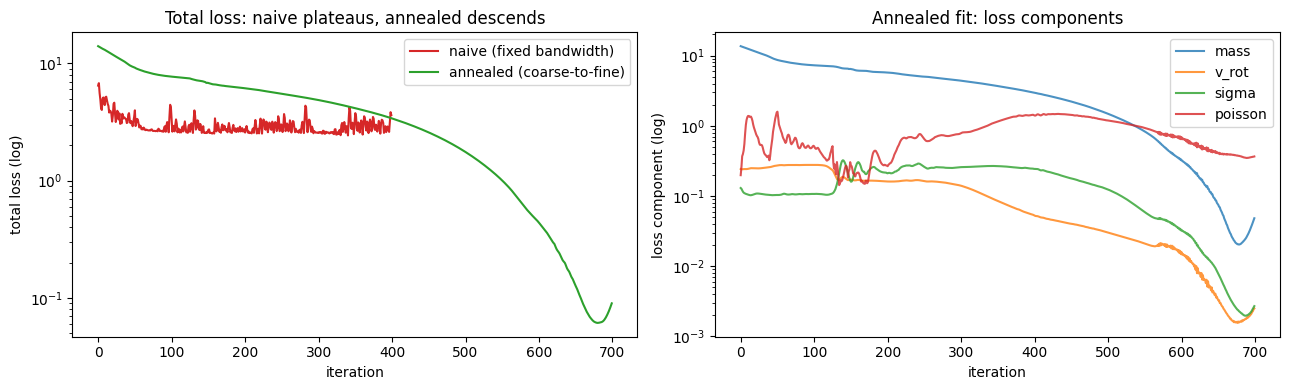

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hn['loss'], color='tab:red', label='naive (fixed bandwidth)')
axes[0].plot(h['loss'], color='tab:green', label='annealed (coarse-to-fine)')
axes[0].set_yscale('log'); axes[0].set_xlabel('iteration'); axes[0].set_ylabel('total loss (log)')
axes[0].set_title('Total loss: naive plateaus, annealed descends'); axes[0].legend()

axes[1].plot(h['mass_loss'], label='mass', alpha=0.8)
axes[1].plot(h['vrot_loss'], label='v_rot', alpha=0.8)
axes[1].plot(h['sigma_loss'], label='sigma', alpha=0.8)
axes[1].plot(h['poisson_penalty'], label='poisson', alpha=0.8, color='tab:red')
axes[1].set_yscale('log'); axes[1].set_xlabel('iteration'); axes[1].set_ylabel('loss component (log)')
axes[1].set_title('Annealed fit: loss components'); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Map Comparison: Observed vs. Far Init vs. Naive vs. Annealed

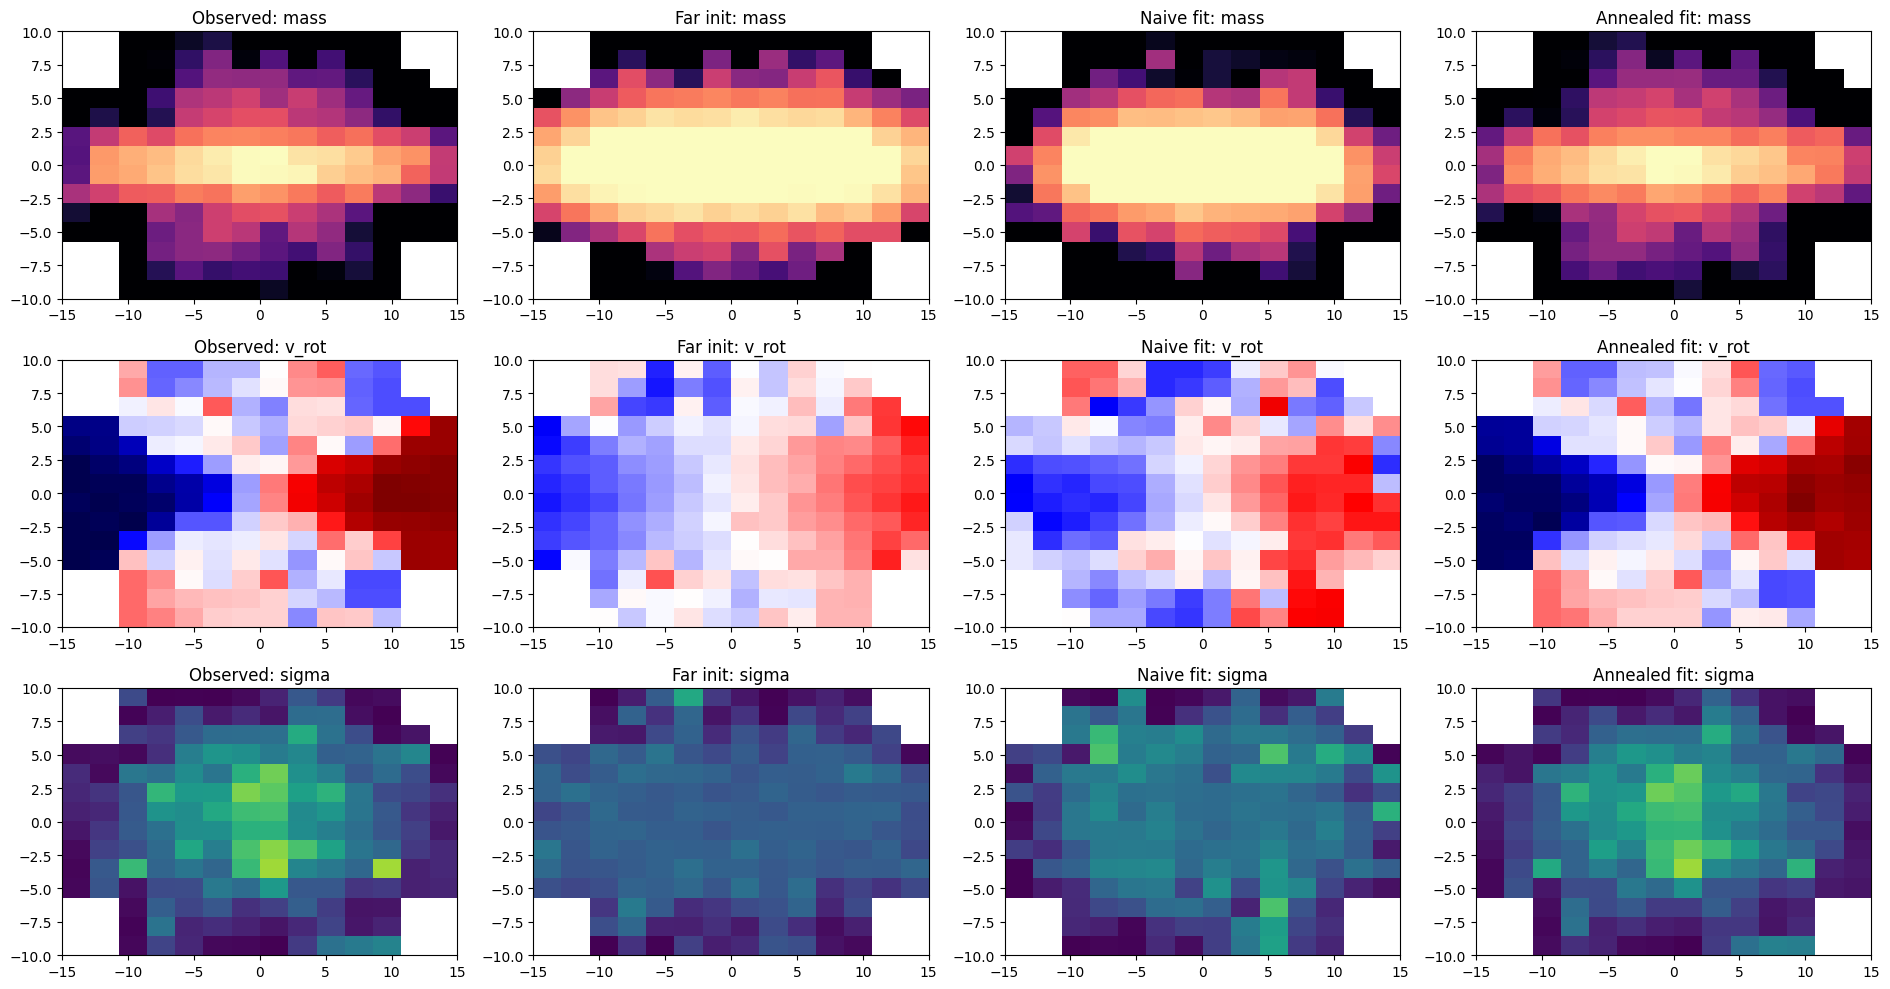

In [8]:
final_maps = generate_edge_on_maps(
    mapper, result['pot_params'], result['disk_df_params'], result['bulge_df_params'],
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
    extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED,
)
naive_maps = generate_edge_on_maps(
    mapper, result_naive['pot_params'], result_naive['disk_df_params'], result_naive['bulge_df_params'],
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
    extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED,
)

fig, axes = plt.subplots(3, 4, figsize=(19, 10))
for col, (name, m) in enumerate([('Observed', obs_maps), ('Far init', init_maps),
                                  ('Naive fit', naive_maps), ('Annealed fit', final_maps)]):
    plot_maps_row(axes[:, col], m, mass_mask, name, vmax_mass)
plt.tight_layout(); plt.show()

## 7. Parameter Recovery

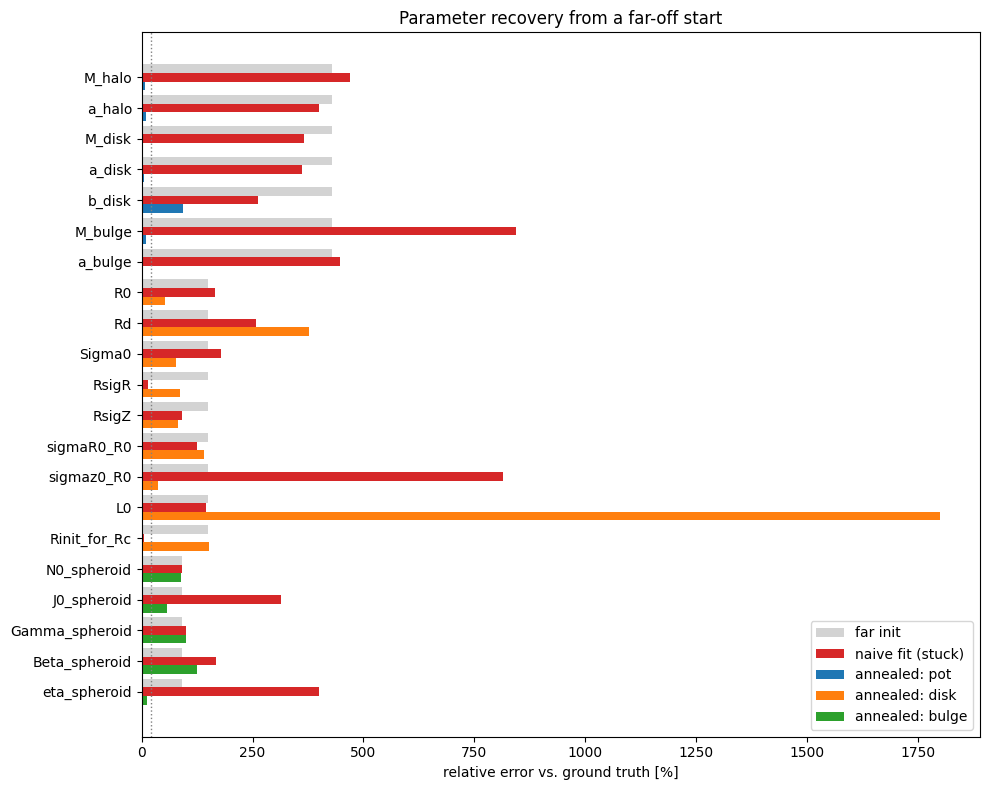

parameter                true     init    naive  annealed
M_halo                  1e+12     430%     471%        8%
a_halo                     20     430%     400%        9%
M_disk                  5e+10     430%     365%        2%
a_disk                      3     430%     362%        6%
b_disk                    0.3     430%     263%       93%
M_bulge                 1e+10     430%     844%       10%
a_bulge                     1     430%     447%        1%
R0                          8     150%     165%       53%
Rd                          3     150%     257%      378%
Sigma0                   1000     150%     178%       77%
RsigR                       6     150%      14%       86%
RsigZ                       6     150%      92%       82%
sigmaR0_R0                 35     150%     124%      140%
sigmaz0_R0                 20     150%     815%       37%
L0                         10     150%     144%     1801%
Rinit_for_Rc                8     150%       6%      151%
N0_spheroid   

In [9]:
all_true = {**pot_params_true, **disk_df_params_true, **bulge_df_params_true}
all_init = {**pot_params_init, **disk_df_params_init, **bulge_df_params_init}
_, _, err_naive = recovery(result_naive)
_, _, err_anneal = recovery(result)
keys = list(all_true.keys())
groups = (['pot_params']*len(pot_params_true) + ['disk_df_params']*len(disk_df_params_true)
          + ['bulge_df_params']*len(bulge_df_params_true))
gc = {'pot_params': 'tab:blue', 'disk_df_params': 'tab:orange', 'bulge_df_params': 'tab:green'}

init_err = [abs(all_init[k]-all_true[k])/abs(all_true[k])*100 for k in keys]
fig, ax = plt.subplots(figsize=(10, 8))
yv = np.arange(len(keys))
ax.barh(yv-0.28, init_err, height=0.28, color='lightgray', label='far init')
ax.barh(yv,      [err_naive[k] for k in keys], height=0.28, color='tab:red', label='naive fit')
ax.barh(yv+0.28, [err_anneal[k] for k in keys], height=0.28,
        color=[gc[g] for g in groups], label='annealed fit')
ax.set_yticks(yv); ax.set_yticklabels(keys); ax.invert_yaxis()
ax.set_xlabel('relative error vs. ground truth [%]'); ax.axvline(20, color='gray', ls=':', lw=1)
ax.set_title('Parameter recovery from a far-off start')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='lightgray', label='far init'),
                   Patch(facecolor='tab:red', label='naive fit (stuck)'),
                   Patch(facecolor='tab:blue', label='annealed: pot'),
                   Patch(facecolor='tab:orange', label='annealed: disk'),
                   Patch(facecolor='tab:green', label='annealed: bulge')], loc='lower right')
plt.tight_layout(); plt.show()

print(f"{'parameter':16s} {'true':>12s} {'init':>8s} {'naive':>8s} {'annealed':>9s}")
for k in keys:
    print(f"{k:16s} {all_true[k]:12.4g} {init_err[keys.index(k)]:7.0f}% {err_naive[k]:7.0f}% {err_anneal[k]:8.0f}%")

## 8. Residual Degeneracy and Multi-Start

Annealing fixes the *optimization* failure — the annealed fit reaches a low data-fit loss comparable to what a nearby start achieves, and the maps match well (Section 6). But some parameters are still recovered poorly. That remaining error is **not** an optimizer problem: a single edge-on projection genuinely under-constrains certain parameter combinations (e.g. the spheroid DF's `Beta_spheroid`/`eta_spheroid` trade off while barely changing the maps), so different parameter sets fit the data almost equally well.

`fit_multistart` runs several scattered starts and keeps the lowest-loss result; the spread across restarts is itself a read-out of which parameters are well-constrained. It cannot break a true degeneracy (all restarts reach nearly the same loss), but it improves robustness and flags the ill-constrained directions. Genuinely resolving them needs more information: multiple viewing angles, higher-order (Gauss-Hermite `h3/h4`) kinematics, or informative priors on the DF shape parameters.

In [10]:
ms = fit_multistart(
    mapper, obs_maps,
    pot_params_init, disk_df_params_init, bulge_df_params_init,
    n_restarts=4, restart_log_sigma=0.4, restart_seed=1,
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
    extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED,
    loss_weights=(1.0, 1.0, 1.0, 0.1), poisson_kwargs={},
    learning_rate=0.05, n_steps=700, anneal_bandwidth=(8.0, 0.5),
)
med, ng, _ = recovery(ms)
print("per-restart final losses:", [f"{x:.3f}" for x in ms['final_losses']])
print(f"best restart index {ms['best_index']}, loss {ms['history']['loss'][-1]:.3f}")
print(f"best-restart median param error {med:.0f}%, within 20%: {ng}/21")

per-restart final losses: ['0.090', '1.162', 'inf', 'inf']
best restart index 0, loss 0.090
best-restart median param error 77%, within 20%: 7/21


## 9. Summary — Fitting From a Far-Off Start

What goes wrong for a far starting guess, and the fix for each:

| Symptom | Cause | Fix |
|---|---|---|
| `NaN` immediately | rejection envelope from a fixed action point underflows to 0 → division by zero | auto-calibrated envelope (`envelope_max=None`, now used by the pipeline) |
| Fit pulled off-target | Poisson penalty biased by KDE normalization, not minimized at truth | `shape_only=True` (default) + modest weight `w_poisson≈0.1` |
| Loss plateaus high, won't descend | model/observed maps don't overlap → vanishing gradient in masked log-mass term | **bandwidth annealing** `anneal_bandwidth=(h_start,h_end)` (graduated optimization) |
| Some params still off despite low loss | genuine degeneracy of a single edge-on projection | multi-start + more data (extra views, `h3/h4`, priors) |

**Recommended recipe for a far start:** `fit(..., loss_weights=(1,1,1,0.1), anneal_bandwidth=(8.0, 0.5), n_steps>=700)`, optionally wrapped in `fit_multistart`.

**Using real observations:** build `obs_maps` with the same keys (`'mass'`, `'v_rot'`, `'sigma'`, `'x_edges'`, `'z_edges'`) from real maps on a grid matching `grid_size`/`extent_x`/`extent_z`, then call `fit(...)` / `fit_multistart(...)` as above.